Zomato Dataset Analysis 

## Step 1: Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 



In [7]:
pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Load the data

The csv file has some special characters (like currency symbols), so normal reading gives an error.
That's why I used `encoding="latin-1"`.

In [8]:
data = pd.read_csv(r"C:\Users\sakshi fauzdar\Downloads\zomato.csv", encoding="latin-1")
country_data = pd.read_excel(r"C:\Users\sakshi fauzdar\Downloads\Country-Code.xlsx")

print("Shape of data:", data.shape)
data.head()


Shape of data: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [9]:
# Let's check the column names and data types
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

## Step 3: Clean the data

Simple cleaning steps:
1. Add the real country name (right now we only have a country code number)
2. Remove duplicate restaurants
3. Rename some long column names to shorter, easy names
4. Check for missing values


In [10]:
# 1. Merge country name using Country Code
data = data.merge(country_data, on="Country Code", how="left")

# 2. Remove duplicate rows (same restaurant appearing twice)
data = data.drop_duplicates(subset="Restaurant ID")

# 3. Rename columns to simpler names
data = data.rename(columns={
    "Average Cost for two": "Cost_for_two",
    "Aggregate rating": "Rating",
    "Price range": "Price_range"
})

print("Shape after cleaning:", data.shape)
data.head()


Shape after cleaning: (9551, 22)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Cost_for_two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price_range,Rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [11]:
# 4. Check missing values in each column
data.isnull().sum()


Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Cost_for_two            0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price_range             0
Rating                  0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

In [12]:
# Some restaurants have Rating = 0 because nobody voted yet.
# Let's separate those out so our averages are not affected by them.
rated_data = data[data["Votes"] > 0]

print("Total restaurants:", len(data))
print("Restaurants with at least 1 vote:", len(rated_data))


Total restaurants: 9551
Restaurants with at least 1 vote: 8457


## Step 4: Basic statistics (NumPy + Pandas)

In [13]:
# describe() gives min, max, mean, etc. in one line
data[["Cost_for_two", "Rating", "Votes", "Price_range"]].describe()


,Cost_for_two,Rating,Votes,Price_range
count,9551.000000,9551.000000,9551.000000,9551.000000
mean,1199.210763,2.666370,156.909748,1.804837
std,16121.183073,1.516378,430.169145,0.905609
min,0.000000,0.000000,0.000000,1.000000
25%,250.000000,2.500000,5.000000,1.000000
50%,400.000000,3.200000,31.000000,2.000000
75%,700.000000,3.700000,131.000000,2.000000
max,800000.000000,4.900000,10934.000000,4.000000


In [14]:
# Using NumPy to calculate mean and median manually
avg_rating = np.mean(rated_data["Rating"])
median_rating = np.median(rated_data["Rating"])

print("Average rating:", round(avg_rating, 2))
print("Median rating:", round(median_rating, 2))


Average rating: 3.01
Median rating: 3.3


## Step 5: Answering simple questions about the data

### Q1. Which cities have the most restaurants?

In [15]:
top_cities = data["City"].value_counts().head(10)
top_cities


City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

### Q2. Which cuisines are most common?

In [16]:
# Cuisines column has multiple cuisines in one cell, separated by commas
# Example: "North Indian, Chinese" -> we split this into 2 separate rows

cuisine_list = data["Cuisines"].dropna().str.split(",")
all_cuisines = cuisine_list.explode().str.strip()

top_cuisines = all_cuisines.value_counts().head(10)
top_cuisines


Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

### Q3. Does online delivery affect the rating?

In [17]:
rated_data.groupby("Has Online delivery")["Rating"].mean().round(2)


Has Online delivery
No     2.90
Yes    3.28
Name: Rating, dtype: float64

### Q4. Does price range affect the rating?

In [18]:
rated_data.groupby("Price_range")["Rating"].mean().round(2)


Price_range
1    2.50
2    3.13
3    3.72
4    3.85
Name: Rating, dtype: float64

## Step 6: Charts (Matplotlib)

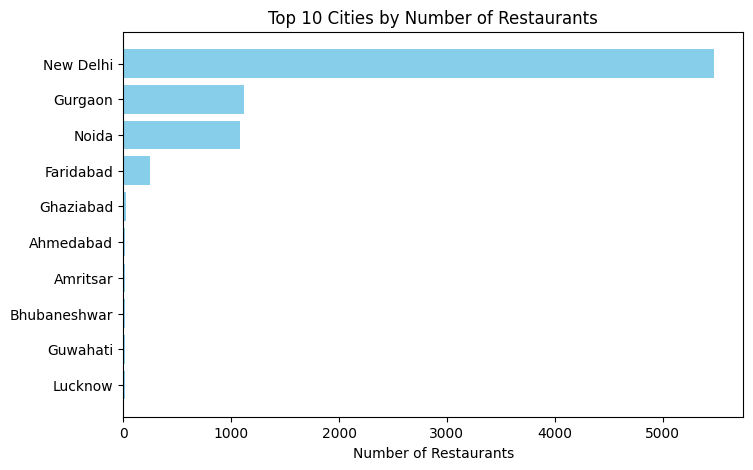

In [19]:
# Chart 1: Top 10 cities
plt.figure(figsize=(8,5))
plt.barh(top_cities.index, top_cities.values, color="skyblue")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.gca().invert_yaxis()   # biggest bar on top
plt.show()


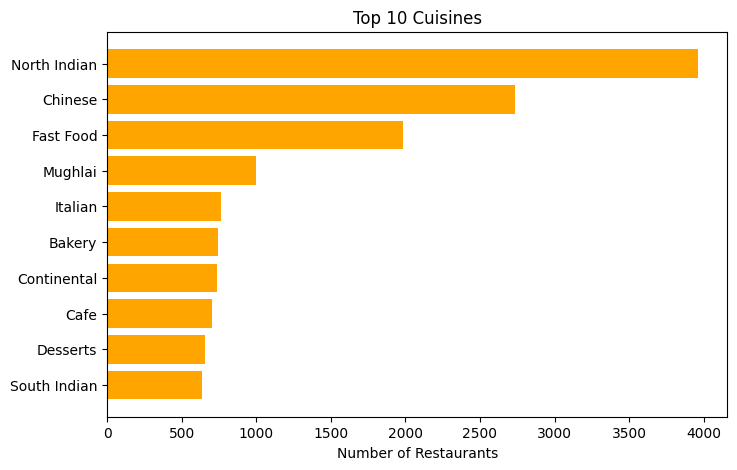

In [20]:
# Chart 2: Top 10 cuisines
plt.figure(figsize=(8,5))
plt.barh(top_cuisines.index, top_cuisines.values, color="orange")
plt.title("Top 10 Cuisines")
plt.xlabel("Number of Restaurants")
plt.gca().invert_yaxis()
plt.show()


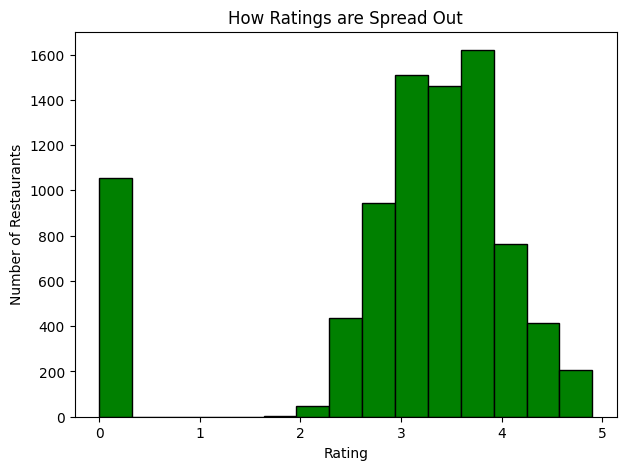

In [21]:
# Chart 3: Rating distribution (histogram)
plt.figure(figsize=(7,5))
plt.hist(rated_data["Rating"], bins=15, color="green", edgecolor="black")
plt.title("How Ratings are Spread Out")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()


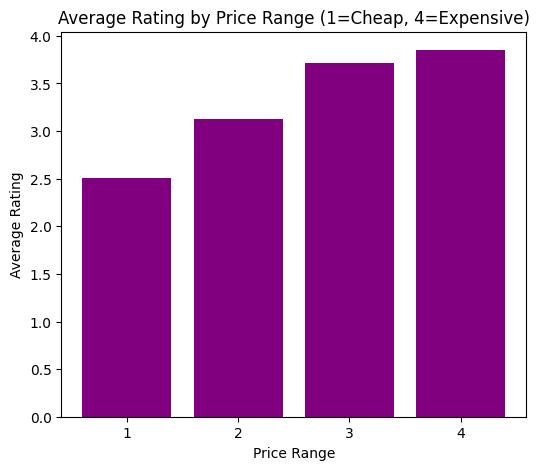

In [22]:
# Chart 4: Average rating by price range
price_rating = rated_data.groupby("Price_range")["Rating"].mean()

plt.figure(figsize=(6,5))
plt.bar(price_rating.index.astype(str), price_rating.values, color="purple")
plt.title("Average Rating by Price Range (1=Cheap, 4=Expensive)")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()


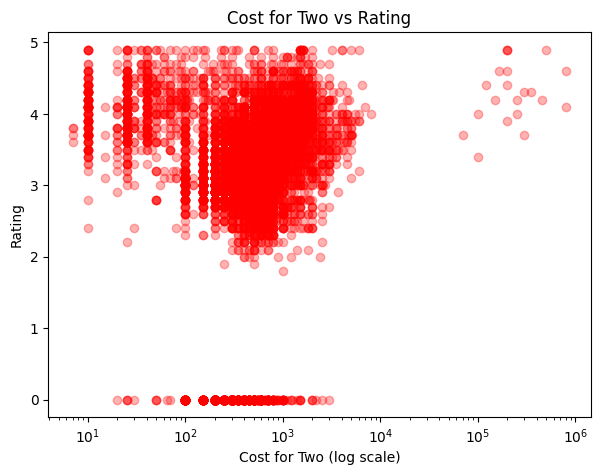

In [23]:
# Chart 5: Cost vs Rating (scatter plot)
plt.figure(figsize=(7,5))
plt.scatter(rated_data["Cost_for_two"], rated_data["Rating"], alpha=0.3, color="red")
plt.xscale("log")   # log scale because cost values vary a lot
plt.title("Cost for Two vs Rating")
plt.xlabel("Cost for Two (log scale)")
plt.ylabel("Rating")
plt.show()


## Step 7: Save the clean data

This is an important step. We save a clean CSV file now.
Later, we will:
- Import this CSV into **SQL** to practice queries
- Import this CSV into **Power BI** to build a dashboard with charts and filters


In [ ]:
columns_to_keep = [
    "Restaurant ID", "Restaurant Name", "Country", "City", "Locality",
    "Cuisines", "Cost_for_two", "Currency", "Has Table booking",
    "Has Online delivery", "Price_range", "Rating", "Rating text", "Votes"
]

clean_data = data[columns_to_keep]
clean_data.to_csv("zomato_clean.csv", index=False)

print("Saved zomato_clean.csv with shape:", clean_data.shape)
clean_data.head()


Saved zomato_clean.csv with shape: (9551, 14)


,Restaurant ID,Restaurant Name,Country,City,Locality,Cuisines,Cost_for_two,Currency,Has Table booking,Has Online delivery,Price_range,Rating,Rating text,Votes
0,6317637,Le Petit Souffle,Phillipines,Makati City,"Century City Mall, Poblacion, Makati City","French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,3,4.8,Excellent,314
1,6304287,Izakaya Kikufuji,Phillipines,Makati City,"Little Tokyo, Legaspi Village, Makati City",Japanese,1200,Botswana Pula(P),Yes,No,3,4.5,Excellent,591
2,6300002,Heat - Edsa Shangri-La,Phillipines,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City","Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,4,4.4,Very Good,270
3,6318506,Ooma,Phillipines,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Sushi",1500,Botswana Pula(P),No,No,4,4.9,Excellent,365
4,6314302,Sambo Kojin,Phillipines,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Korean",1500,Botswana Pula(P),Yes,No,4,4.8,Excellent,229
